# Compare smooth vs non smoothed psfs

In [30]:
import sys,os,os.path

from glob import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

sys.path.append("/gluster/data/next/software/IC_john/")
sys.path.append(os.path.expanduser('~/code/eol_hsrl_python'))
os.environ['ICTDIR']='/gluster/data/next/software/IC_john/'

from invisible_cities.io.dst_io        import load_dst, load_dsts
from invisible_cities.cities.beersheba import cut_over_Q
from invisible_cities.cities.beersheba import drop_isolated 
from invisible_cities.cities.beersheba import deconvolve_signal
from invisible_cities.reco.deconv_functions import deconvolution_input
from invisible_cities.reco.deconv_functions import InterpolationMethod
from invisible_cities.cities.beersheba import DeconvolutionMode
from invisible_cities.cities.beersheba          import CutType
from invisible_cities.database.load_db      import DataSiPM
from invisible_cities.database.load_db      import DetDB

from invisible_cities.evm.event_model        import HitEnergy

##
# FUNCTIONS
##
def raw_plotter(q, evt, pitch = 15.55, param = 'Q', title = None):
    '''
    just plots the hits, nothing smart
    '''

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    xx = np.arange(q.X.min(), q.X.max() + pitch, pitch)
    yy = np.arange(q.Y.min(), q.Y.max() + pitch, pitch)
    zz = np.sort(q.Z.unique())

    axes[0].hist2d(q.X, q.Y, bins=[xx, yy], weights=q[param], cmin=0.0001);
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    axes[1].hist2d(q.X, q.Z, bins=[xx, zz], weights=q[param], cmin=0.0001);
    axes[1].set_xlabel('X (mm)');
    axes[1].set_ylabel('Z (mm)');


    axes[2].hist2d(q.Y, q.Z, bins=[yy, zz], weights=q[param], cmin=0.0001);
    axes[2].set_xlabel('Y (mm)');
    axes[2].set_ylabel('Z (mm)');
    if title is None:
        fig.suptitle(f"raw plot event {evt}")
    else:
        fig.suptitle(title)
    plt.show(fig)




In [31]:

data_path = '/gluster/data/next/files/TOPOLOGY_John/N100_data/15591/230725/ldc1/'
data_path = glob(f'{data_path}*')
kr_data = load_dst(data_path[0], 'RECO', 'Events')

In [32]:
# select psf for the MC
# data psf, dodgy, results in weird behaviour
# psf_path = '/gluster/data/next/files/TOPOLOGY_John/N100_data/maps/210525_full_25us.psf'
# MC psf, normal for MC, lets see if the data can handle it.
#psf_path = '/gluster/data/next/files/TOPOLOGY_John/MC_data/kr_20260N_full_fast_lowq_thr/data/remove_low_sipms/kr_202601_full/merged_psfs/kr_202601_full_full_25us.psf'
psf_path        = '/gluster/data/next/files/TOPOLOGY_John/N100_data/maps/PSF_15539_z100_xy2.0_130125.psf'
# smooth psf of PSF_15539_z100_xy2.0_130125.psf
psf_path_smooth = '/gluster/data/next/files/TOPOLOGY_John/N100_data/maps/smoother_R15539.psf'

In [116]:
full_data = []
for i in tqdm(range(0, 2000)):
    try:
        data          = load_dst(data_path[i], 'RECO', 'Events')
        data['event'] = i

        if ((data.Ec.sum() > 1.4) & (data.Ec.sum() < 1.8)):
            full_data.append(data)
    except Exception as e:
        print('e')

data = pd.concat(full_data)


  1%|▏         | 26/2000 [00:00<01:06, 29.74it/s]

e


  2%|▏         | 46/2000 [00:01<01:02, 31.40it/s]

e


  4%|▍         | 82/2000 [00:02<01:06, 28.76it/s]

...

 98%|█████████▊| 1953/2000 [01:23<00:01, 23.99it/s]

e


 99%|█████████▉| 1981/2000 [01:24<00:00, 21.54it/s]

e


100%|██████████| 2000/2000 [01:25<00:00, 23.43it/s]


,event,time,npeak,Xpeak,Ypeak,nsipm,X,Y,Xrms,Yrms,Z,Q,E,Qc,Ec,track_id,Ep
0,1353,1.752208e+09,21,44.875748,12.727324,1,134.375,-371.075,0.0,0.0,15.021875,7.953960,3.245263,-1.0,1.735225e-05,-1,-1.0
1,1353,1.752208e+09,21,44.875748,12.727324,1,149.925,399.425,0.0,0.0,15.021875,8.562572,3.493580,-1.0,1.958593e-05,-1,-1.0
2,1353,1.752208e+09,21,44.875748,12.727324,1,-173.625,-356.525,0.0,0.0,18.266125,7.462811,0.050647,-1.0,2.742808e-07,-1,-1.0
3,1353,1.752208e+09,21,44.875748,12.727324,1,227.675,137.075,0.0,0.0,18.266125,9.375326,0.063627,-1.0,3.128363e-07,-1,-1.0
4,1353,1.752208e+09,21,44.875748,12.727324,1,-50.225,-479.925,0.0,0.0,22.522625,7.774975,5.736502,-1.0,5.246945e-05,-1,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1030,1353,1.752208e+09,21,44.875748,12.727324,1,-112.425,-356.525,0.0,0.0,262.632000,7.857091,370.086467,-1.0,2.017002e-03,-1,-1.0
1031,1353,1.752208e+09,21,44.875748,12.727324,1,-50.225,-78.625,0.0,0.0,278.610875,7.694237,221.159156,-1.0,1.049119e-03,-1,-1.0
1032,1353,1.752208e+09,21,44.875748,12.727324,1,-3.575,-433.275,0.0,0.0,282.556375,7.913202,81.207262,-1.0,4.745848e-04,-1,-1.0
1033,1353,1.752208e+09,21,44.875748,12.727324,1,257.775,122.025,0.0,0.0,286.551625,10.624048,100.793127,-1.0,5.053280e-04,-1,-1.0


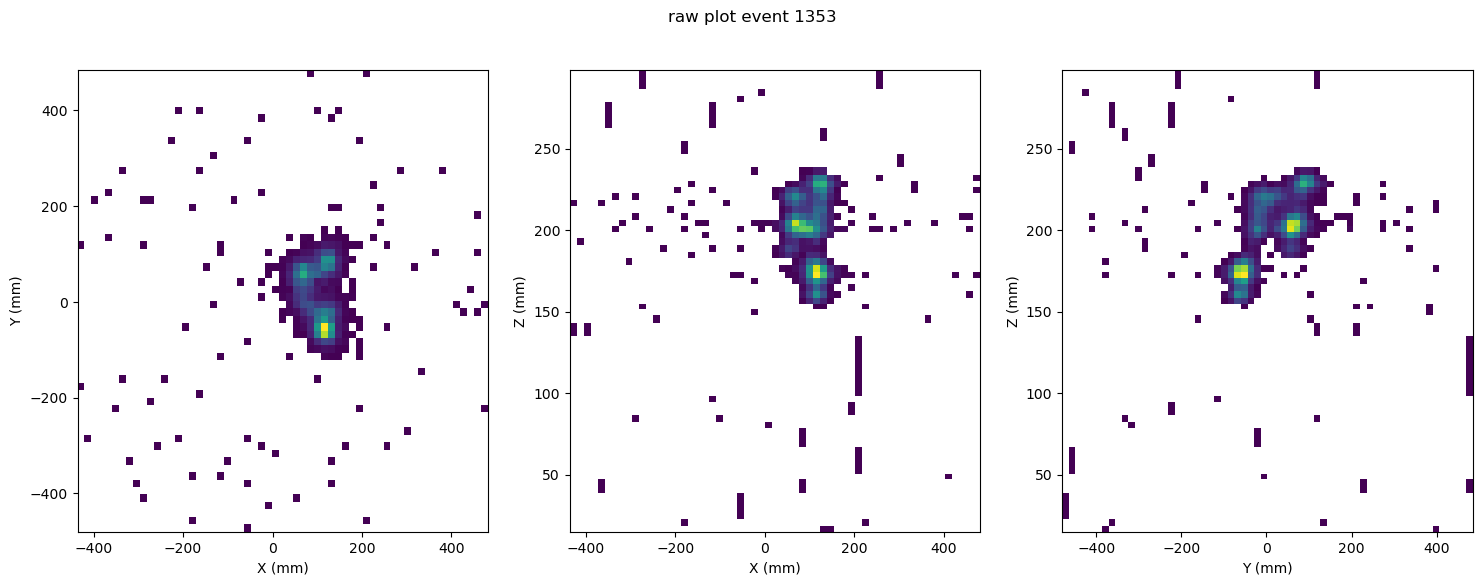

In [123]:
# sanity check
N = 28 # 19 is good 
EOI = data[data.event == data.event.unique()[N]]
display(EOI)
raw_plotter(EOI, EOI.event.unique()[0])

In [170]:
# apply standard prescription beersheba
# Parameters involved in beersheba city and the deconvolution.
nhits = 3
deconv_params = dict(
  q_cut            = 5, #5 for 6mm  - 5 for 6mm
  drop_dist        = [16, 16, 4],
  #psf_fname        = f'/Users/halmamol/NEXT/PSF_FLEX100_mask{dist}_lowQE.h5',     
  psf_fname        = psf_path,     
  e_cut            = 3e-4, #15 for 6mm  - 15 for 6mm
  n_iterations     = 150, #150 for 6mm  - 150 for 6mm
  iteration_tol    =  1e-10,
  sample_width     = [15.55, 15.55],
  bin_size         = [ 2,  2],
  diffusion        = (1., 1.),
  n_dim            = 2,
  deconv_mode      = DeconvolutionMode.joint,
  cut_type         = CutType.abs,
  energy_type      = HitEnergy.Ec,
  satellite_params = dict(satellite_start_iter = 20, satellite_max_size = 4, e_cut = 1e-6))#,

deconv_params_smooth = dict(
  q_cut            = 5, #5 for 6mm  - 5 for 6mm
  drop_dist        = [16, 16, 4],
  #psf_fname        = f'/Users/halmamol/NEXT/PSF_FLEX100_mask{dist}_lowQE.h5',     
  psf_fname        = psf_path_smooth,     
  e_cut            = 1e-6, #15 for 6mm  - 15 for 6mm
  n_iterations     = 150, #150 for 6mm  - 150 for 6mm
  iteration_tol    =  1e-10,
  sample_width     = [15.55, 15.55],
  bin_size         = [ 2,  2],
  diffusion        = (1., 1.),
  n_dim            = 2,
  deconv_mode      = DeconvolutionMode.joint,
  cut_type         = CutType.abs,
  energy_type      = HitEnergy.Ec,
  satellite_params = dict(satellite_start_iter = 20, satellite_max_size = 4, e_cut = 1e-6))#,

deconv_params_   = {k : v for k, v in deconv_params.items() if k not in ['q_cut', 'drop_dist']}


deconv_params_smooth_   = {k : v for k, v in deconv_params_smooth.items() if k not in ['q_cut', 'drop_dist']}

# Couple of functions used in beersheba.
# these are the same across both, so who cares?
cut_sensors       = cut_over_Q   (deconv_params['q_cut'    ], ['E', 'Ec'])
drop_sensors      = drop_isolated(deconv_params['drop_dist'], ['E', 'Ec'], nhits)


#deconvolve = deconvolve_signal(DataSiPM(detector_db, run_number))

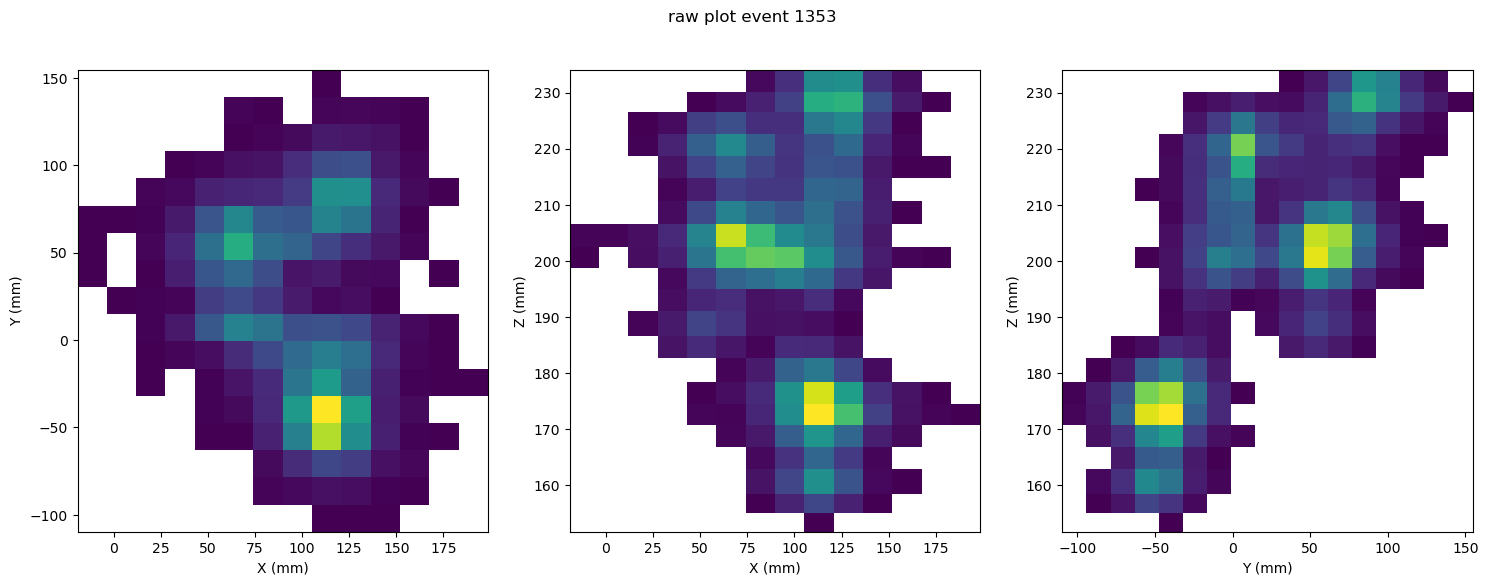

In [124]:
EOI_cut = cut_sensors(EOI)
EOI_drop = drop_sensors(EOI_cut)

raw_plotter(EOI_drop, EOI_drop.event.unique()[0])

In [102]:
# create beersheba object
datatype = 'DATA'
detector_db = '/gluster/data/next/software/IC_john/IC/invisible_cities/database/localdb.NEXT100DB.sqlite3'
run_number = 0 
deconvolver        = deconvolve_signal(DataSiPM(detector_db, run_number), **deconv_params_)
deconvolver_smooth = deconvolve_signal(DataSiPM(detector_db, run_number), **deconv_params_smooth_)

In [125]:
## SMOOTH VERSION

from pathlib import Path
from datetime import datetime# generate output folder
global_timestamp = datetime.now().strftime("%H%M%S_%Y%m%d")
folder = f'gif_images/{global_timestamp}'
path = Path(folder)
path.mkdir(parents=True, exist_ok = True)
print(f'Generated smooth folder {path}')

# for gif creation
png_list = []

n_iterations_max = 200 
iteration_step   = 20
for i in range(10, n_iterations_max, iteration_step):
    print(i)
    deconv_params_smooth_['n_iterations'] = i
    deconvolver = deconvolve_signal(DataSiPM(detector_db, run_number), **deconv_params_smooth_)
    EOI_deco = deconvolver(EOI_drop)
    
    # plot direct comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    xx = np.arange(EOI_deco.X.min(), EOI_deco.X.max() + 2, 2)# + pitch, pitch)
    yy = np.arange(EOI_deco.Y.min(), EOI_deco.Y.max() + 2, 2)# + pitch, pitch)
    zz = EOI_deco.Z.unique()

    axes[0].hist2d(EOI_deco.X, EOI_deco.Y, bins=[xx, yy], weights=EOI_deco.E, cmin = np.finfo(float).eps);
    if (datatype == 'MC'):
        axes[0].scatter(xt, yt,  alpha=0.1, color='red')
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    axes[1].hist2d(EOI_deco.X, EOI_deco.Z, bins=[xx, zz], weights=EOI_deco.E, cmin=np.finfo(float).eps);
    if (datatype == 'MC'):
        axes[1].scatter(xt, zt,  alpha=0.1, color='red')
    axes[1].set_xlabel('X (mm)');
    axes[1].set_ylabel('Z (mm)');

    axes[2].hist2d(EOI_deco.Y, EOI_deco.Z, bins=[yy, zz], weights=EOI_deco.E, cmin=np.finfo(float).eps);
    if (datatype == 'MC'):
        axes[2].scatter(yt, zt,  alpha=0.1, color='red')
    axes[2].set_xlabel('Y (mm)');
    axes[2].set_ylabel('Z (mm)');

    xx = np.arange(EOI_drop.X.min(), EOI_drop.X.max())# + pitch, pitch)
    yy = np.arange(EOI_drop.Y.min(), EOI_drop.Y.max())# + pitch, pitch)
    zz = EOI_drop.Z.unique()

    axes[0].hist2d(EOI_drop.X, EOI_drop.Y, bins=[xx, yy], weights=EOI_drop.Q, cmin = np.finfo(float).eps, cmap = 'cool');
    if (datatype == 'MC'):
        axes[0].scatter(xt, yt,  alpha=0.1, color='red')
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    axes[1].hist2d(EOI_drop.X, EOI_drop.Z, bins=[xx, zz], weights=EOI_drop.Q, cmin=np.finfo(float).eps, cmap = 'cool');
    if (datatype == 'MC'):
        axes[1].scatter(xt, zt,  alpha=0.1, color='red')
    axes[1].set_xlabel('X (mm)');
    axes[1].set_ylabel('Z (mm)');

    axes[2].hist2d(EOI_drop.Y, EOI_drop.Z, bins=[yy, zz], weights=EOI_drop.Q, cmin=np.finfo(float).eps, cmap = 'cool');
    if (datatype == 'MC'):
        axes[2].scatter(yt, zt,  alpha=0.1, color='red')
    axes[2].set_xlabel('Y (mm)');
    axes[2].set_ylabel('Z (mm)');
    fig.suptitle(f'iteration_{i} - timestamp {global_timestamp}')
    plt.savefig(f'{path}/iter_{i}.png')
    png_list.append(f'{path}/iter_{i}.png')
    plt.close()

Generated smooth folder gif_images/162423_20260325
10
30
50
70
90
110
130
150
170
190


In [126]:
import imageio.v2 as imageio


with imageio.get_writer(f"gif_images/{global_timestamp}.gif", mode="I", duration=2, loop = 0) as writer:
    for file in png_list:
        writer.append_data(imageio.imread(file))

In [171]:
from pathlib import Path
from datetime import datetime# generate output folder
global_timestamp = datetime.now().strftime("%H%M%S_%Y%m%d")
folder = f'gif_images/{global_timestamp}'
path = Path(folder)
path.mkdir(parents=True, exist_ok = True)
print(f'Generated non-smoothed folder {path}')

# for gif creation
png_list = []

n_iterations_max = 200 
iteration_step   = 20
for i in range(10, n_iterations_max, iteration_step):
    print(i)
    deconv_params_['n_iterations'] = i
    deconvolver = deconvolve_signal(DataSiPM(detector_db, run_number), **deconv_params_)
    EOI_deco = deconvolver(EOI_drop)
    
    # plot direct comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    xx = np.arange(EOI_deco.X.min(), EOI_deco.X.max() + 2, 2)# + pitch, pitch)
    yy = np.arange(EOI_deco.Y.min(), EOI_deco.Y.max() + 2, 2)# + pitch, pitch)
    zz = EOI_deco.Z.unique()

    axes[0].hist2d(EOI_deco.X, EOI_deco.Y, bins=[xx, yy], weights=EOI_deco.E, cmin = np.finfo(float).eps);
    if (datatype == 'MC'):
        axes[0].scatter(xt, yt,  alpha=0.1, color='red')
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    axes[1].hist2d(EOI_deco.X, EOI_deco.Z, bins=[xx, zz], weights=EOI_deco.E, cmin=np.finfo(float).eps);
    if (datatype == 'MC'):
        axes[1].scatter(xt, zt,  alpha=0.1, color='red')
    axes[1].set_xlabel('X (mm)');
    axes[1].set_ylabel('Z (mm)');

    axes[2].hist2d(EOI_deco.Y, EOI_deco.Z, bins=[yy, zz], weights=EOI_deco.E, cmin=np.finfo(float).eps);
    if (datatype == 'MC'):
        axes[2].scatter(yt, zt,  alpha=0.1, color='red')
    axes[2].set_xlabel('Y (mm)');
    axes[2].set_ylabel('Z (mm)');

    xx = np.arange(EOI_drop.X.min(), EOI_drop.X.max())# + pitch, pitch)
    yy = np.arange(EOI_drop.Y.min(), EOI_drop.Y.max())# + pitch, pitch)
    zz = EOI_drop.Z.unique()

    axes[0].hist2d(EOI_drop.X, EOI_drop.Y, bins=[xx, yy], weights=EOI_drop.Q, cmin = np.finfo(float).eps, cmap = 'cool');
    if (datatype == 'MC'):
        axes[0].scatter(xt, yt,  alpha=0.1, color='red')
    axes[0].set_xlabel('X (mm)');
    axes[0].set_ylabel('Y (mm)');

    axes[1].hist2d(EOI_drop.X, EOI_drop.Z, bins=[xx, zz], weights=EOI_drop.Q, cmin=np.finfo(float).eps, cmap = 'cool');
    if (datatype == 'MC'):
        axes[1].scatter(xt, zt,  alpha=0.1, color='red')
    axes[1].set_xlabel('X (mm)');
    axes[1].set_ylabel('Z (mm)');

    axes[2].hist2d(EOI_drop.Y, EOI_drop.Z, bins=[yy, zz], weights=EOI_drop.Q, cmin=np.finfo(float).eps, cmap = 'cool');
    if (datatype == 'MC'):
        axes[2].scatter(yt, zt,  alpha=0.1, color='red')
    axes[2].set_xlabel('Y (mm)');
    axes[2].set_ylabel('Z (mm)');
    fig.suptitle(f'iteration_{i} - timestamp {global_timestamp}')
    plt.savefig(f'{path}/iter_{i}.png')
    png_list.append(f'{path}/iter_{i}.png')
    plt.close()

Generated non-smoothed folder gif_images/165230_20260325
10
30
50
70
90
110
130
150
170
190


In [172]:
import imageio.v2 as imageio


with imageio.get_writer(f"gif_images/{global_timestamp}.gif", mode="I", duration=2, loop = 0) as writer:
    for file in png_list:
        writer.append_data(imageio.imread(file))

# apply beershebashire here to see if it helps

In [129]:
def rebin(df, dx, dy, dz, q_type = 'Qc', e_type = 'E'):
    '''
    Docstring for rebin

    :param df: Description
    :param dx: Description
    :param dy: Description
    :param dz: Description
    '''

    x_edge = np.arange(df.X.min(), df.X.max() + dx, dx)
    y_edge = np.arange(df.Y.min(), df.Y.max() + dy, dy)
    z_edge = np.arange(df.Z.min(), df.Z.max() + dz, dz)

    # meshgrid from voxel centres
    x_centres = (x_edge[:-1] + x_edge[1:]) / 2
    y_centres = (y_edge[:-1] + y_edge[1:]) / 2
    z_centres = (z_edge[:-1] + z_edge[1:]) / 2

    xx, yy, zz = np.meshgrid(x_centres, y_centres, z_centres, indexing='ij')

    He, edges = np.histogramdd(
                            sample = np.vstack([df.X, df.Y, df.Z]).T,
                            bins   = [x_edge, y_edge, z_edge],
                            weights = df[e_type])
    #if 'Q' in df:
    #    Hq, edges = np.histogramdd(
    #                        sample = np.vstack([df.X, df.Y, df.Z]).T,
    #                        bins   = [x_edge, y_edge, z_edge],
    #                        weights = df[q_type])


    rebin_df = pd.DataFrame({
                     "event": df.event.unique()[0],
                     "npeak": df.npeak.unique()[0], # this should not just extract the first peak, very naughty
                     "X"        : xx.ravel(),
                     "Y"        : yy.ravel(),
                     "Z"        : zz.ravel(),
                     "E"        : He.ravel(),
                     "Xpeak"    : 0.0,
                     "Ypeak"    : 0.0 # we overwrite this garbage because we dont use it, naughty
                     })

    # remove empty hits (you need to do this)
    rebin_df = rebin_df[rebin_df['E'] > 0].reset_index(drop=True)

    return rebin_df

# Visual pre-beershebashire

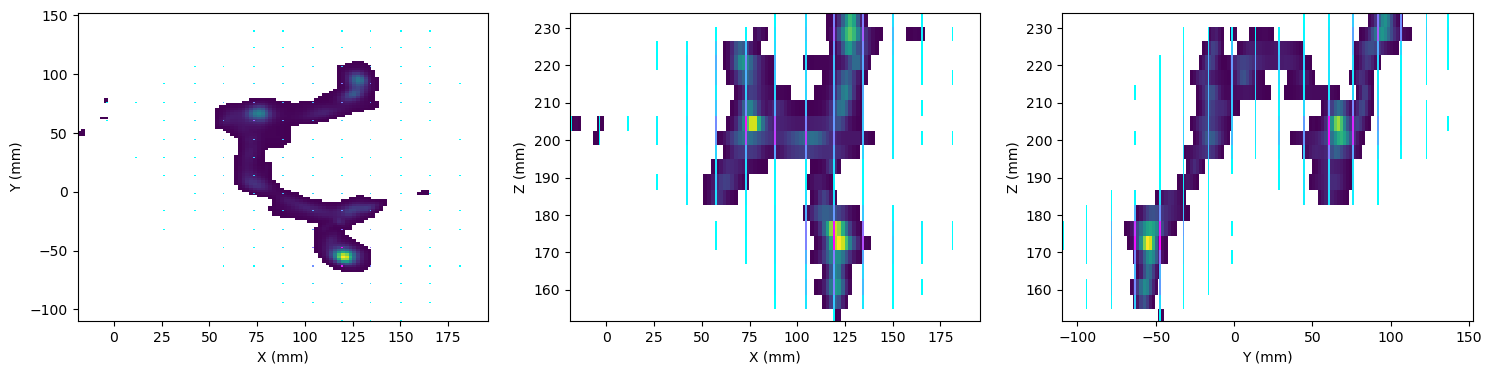

In [163]:
# plot direct comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
pitch = 2
xx = np.arange(EOI_deco.X.min(), EOI_deco.X.max() + pitch, pitch)
yy = np.arange(EOI_deco.Y.min(), EOI_deco.Y.max() + pitch, pitch)
zz = EOI_deco.Z.unique()

axes[0].hist2d(EOI_deco.X, EOI_deco.Y, bins=[xx, yy], weights=EOI_deco.E, cmin = 0.00005);
if (datatype == 'MC'):
    axes[0].scatter(xt, yt,  alpha=0.1, color='red')
axes[0].set_xlabel('X (mm)');
axes[0].set_ylabel('Y (mm)');

axes[1].hist2d(EOI_deco.X, EOI_deco.Z, bins=[xx, zz], weights=EOI_deco.E, cmin=0.00005);
if (datatype == 'MC'):
    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
axes[1].set_xlabel('X (mm)');
axes[1].set_ylabel('Z (mm)');

axes[2].hist2d(EOI_deco.Y, EOI_deco.Z, bins=[yy, zz], weights=EOI_deco.E, cmin=0.0001);
if (datatype == 'MC'):
    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
axes[2].set_xlabel('Y (mm)');
axes[2].set_ylabel('Z (mm)');

xx = np.arange(EOI_drop.X.min(), EOI_drop.X.max())# + pitch, pitch)
yy = np.arange(EOI_drop.Y.min(), EOI_drop.Y.max())# + pitch, pitch)
zz = EOI_drop.Z.unique()

axes[0].hist2d(EOI_drop.X, EOI_drop.Y, bins=[xx, yy], weights=EOI_drop.Q, cmin = 0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[0].scatter(xt, yt,  alpha=0.1, color='red')
axes[0].set_xlabel('X (mm)');
axes[0].set_ylabel('Y (mm)');

axes[1].hist2d(EOI_drop.X, EOI_drop.Z, bins=[xx, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
axes[1].set_xlabel('X (mm)');
axes[1].set_ylabel('Z (mm)');

axes[2].hist2d(EOI_drop.Y, EOI_drop.Z, bins=[yy, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
axes[2].set_xlabel('Y (mm)');
axes[2].set_ylabel('Z (mm)');

fig.show()

In [131]:
display(EOI_deco)

,event,npeak,X,Y,Z,E,Xpeak,Ypeak
0,1353,21,116.875,-48.425,151.710750,5.241139e-07,44.875748,12.727324
1,1353,21,116.875,-46.425,151.710750,1.157618e-06,44.875748,12.727324
2,1353,21,116.875,-44.425,151.710750,6.679567e-08,44.875748,12.727324
3,1353,21,118.875,-50.425,151.710750,5.269401e-07,44.875748,12.727324
4,1353,21,118.875,-48.425,151.710750,4.411922e-05,44.875748,12.727324
...,...,...,...,...,...,...,...,...
11184,1353,21,128.875,87.575,234.081875,6.828372e-08,44.875748,12.727324
11185,1353,21,128.875,89.575,234.081875,1.574528e-07,44.875748,12.727324
11186,1353,21,128.875,91.575,234.081875,1.753912e-07,44.875748,12.727324
11187,1353,21,128.875,93.575,234.081875,1.000605e-07,44.875748,12.727324


In [173]:
# rebin, then drop
rebin_d = (2, 2, 2) # mm
nhits_E = 75
drop_sensors_E      = drop_isolated([4, 4, 4], ['E'], nhits_E)

beershebashire_data = []
for i, df in EOI_deco.groupby('event'):
    print(f'rebinning with {rebin_d[0]}, {rebin_d[1]}, {rebin_d[2]}')
    rebinned_df = rebin(df, rebin_d[0], rebin_d[1], rebin_d[2])
    print(f'rebinned from {df.shape} to {rebinned_df.shape}')
    dropped_df = drop_sensors_E(rebinned_df.copy())
    beershebashire_data.append(dropped_df)

beershebashire_data = pd.concat(beershebashire_data)

rebinning with 2, 2, 2
rebinned from (5760, 8) to (5749, 8)


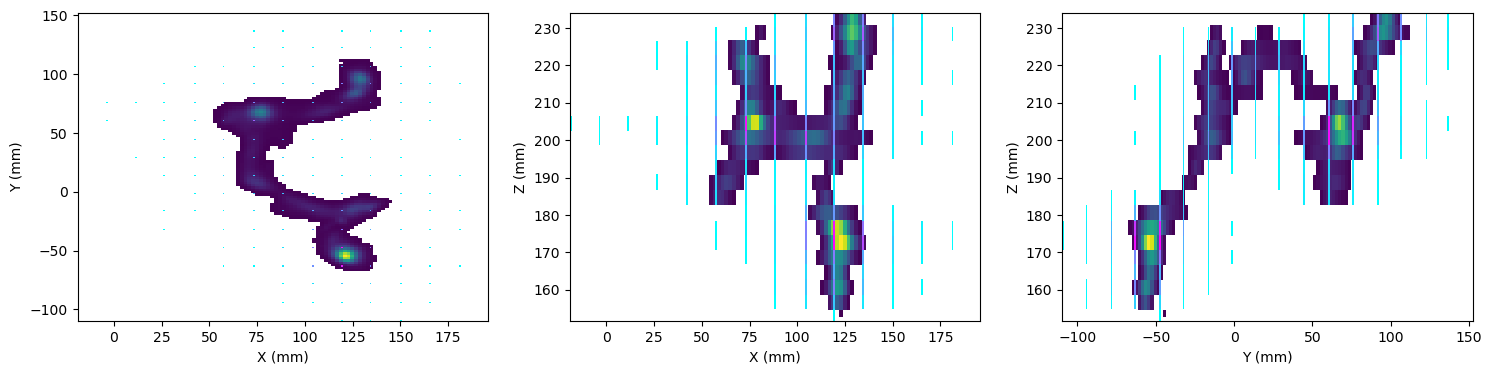

In [175]:
# plot direct comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
pitch = 2
xx = np.arange(beershebashire_data.X.min(), beershebashire_data.X.max() + pitch, pitch)
yy = np.arange(beershebashire_data.Y.min(), beershebashire_data.Y.max() + pitch, pitch)
zz = np.sort(beershebashire_data.Z.unique())

axes[0].hist2d(beershebashire_data.X, beershebashire_data.Y, bins=[xx, yy], weights=beershebashire_data.E, cmin = 0.00003);
if (datatype == 'MC'):
    axes[0].scatter(xt, yt,  alpha=0.1, color='red')
axes[0].set_xlabel('X (mm)');
axes[0].set_ylabel('Y (mm)');

axes[1].hist2d(beershebashire_data.X, beershebashire_data.Z, bins=[xx, zz], weights=beershebashire_data.E, cmin=0.0003);
if (datatype == 'MC'):
    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
axes[1].set_xlabel('X (mm)');
axes[1].set_ylabel('Z (mm)');

axes[2].hist2d(beershebashire_data.Y, beershebashire_data.Z, bins=[yy, zz], weights=beershebashire_data.E, cmin=0.0003);
if (datatype == 'MC'):
    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
axes[2].set_xlabel('Y (mm)');
axes[2].set_ylabel('Z (mm)');

xx = np.arange(EOI_drop.X.min(), EOI_drop.X.max())# + pitch, pitch)
yy = np.arange(EOI_drop.Y.min(), EOI_drop.Y.max())# + pitch, pitch)
zz = EOI_drop.Z.unique()

axes[0].hist2d(EOI_drop.X, EOI_drop.Y, bins=[xx, yy], weights=EOI_drop.Q, cmin = 0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[0].scatter(xt, yt,  alpha=0.1, color='red')
axes[0].set_xlabel('X (mm)');
axes[0].set_ylabel('Y (mm)');

axes[1].hist2d(EOI_drop.X, EOI_drop.Z, bins=[xx, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[1].scatter(xt, zt,  alpha=0.1, color='red')
axes[1].set_xlabel('X (mm)');
axes[1].set_ylabel('Z (mm)');

axes[2].hist2d(EOI_drop.Y, EOI_drop.Z, bins=[yy, zz], weights=EOI_drop.Q, cmin=0.0001, cmap = 'cool');
if (datatype == 'MC'):
    axes[2].scatter(yt, zt,  alpha=0.1, color='red')
axes[2].set_xlabel('Y (mm)');
axes[2].set_ylabel('Z (mm)');

fig.show()

In [162]:
# quick specific check, look at the hits with X > 150
check = beershebashire_data[beershebashire_data.X > 150]
display(check)
print(f"Length of df check: {len(check)}")

,event,npeak,X,Y,Z,E,Xpeak,Ypeak
11015,1353,21,151.875,-9.425,226.71075,1.440072e-07,0.0,0.0
11016,1353,21,151.875,-7.425,226.71075,9.675606e-07,0.0,0.0
11017,1353,21,151.875,-5.425,226.71075,2.488953e-06,0.0,0.0
11018,1353,21,151.875,-3.425,226.71075,2.070373e-06,0.0,0.0
11019,1353,21,151.875,-1.425,226.71075,4.694458e-07,0.0,0.0
11020,1353,21,153.875,-9.425,226.71075,2.898777e-08,0.0,0.0
11021,1353,21,153.875,-7.425,226.71075,4.335614e-07,0.0,0.0
11022,1353,21,153.875,-5.425,226.71075,2.444553e-06,0.0,0.0
11023,1353,21,153.875,-3.425,226.71075,4.265874e-06,0.0,0.0
11024,1353,21,153.875,-1.425,226.71075,1.913844e-06,0.0,0.0


Length of df check: 51


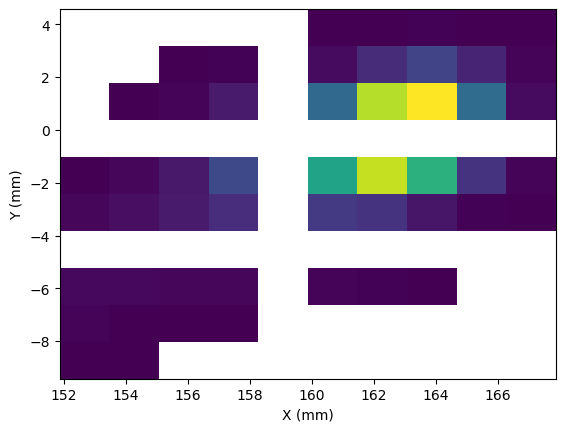

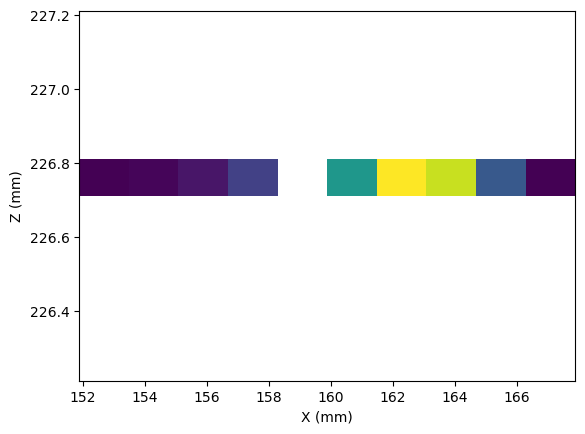

[151.875 153.875 155.875 157.875 159.875 161.875 163.875 165.875 167.875]


In [153]:
plt.hist2d(check.X, check.Y,  weights=check.E, cmin =np.finfo(float).eps , cmap = 'viridis');
plt.xlabel('X (mm)');
plt.ylabel('Y (mm)');
plt.show()

plt.hist2d(check.X, check.Z,  weights=check.E, cmin = np.finfo(float).eps, cmap = 'viridis');
plt.xlabel('X (mm)');
plt.ylabel('Z (mm)');
plt.show()

print(check.X.unique())

In [157]:
from scipy.spatial.distance import pdist, squareform

# Extract XYZ positions
xyz_positions = check[['X', 'Y', 'Z']].values

# Compute pairwise distances
distances = pdist(xyz_positions, metric='euclidean')

print(np.unique(distances))
print(np.sqrt(8))

[ 2.          2.82842712  4.          4.47213595  5.65685425  6.
  6.32455532  7.21110255  8.          8.24621125  8.48528137  8.94427191
 10.         10.19803903 10.77032961 11.3137085  11.66190379 12.
 12.16552506 12.64911064 12.80624847 13.41640786 14.         14.14213562
 14.4222051  14.56021978 15.23154621 15.62049935 16.         16.1245155
 16.4924225  16.97056275 17.08800749 17.20465053 17.88854382 18.43908891
 18.86796226 19.79898987 20.         21.26029163]
2.8284271247461903
